<a href="https://colab.research.google.com/github/HamzaGbada/workshop-iot/blob/main/demo1_traffic_prediction_gnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demo 1: Vehicle Network Prediction with GNN

**Workshop: AI, V2X & Graph Neural Networks for Traffic Systems**

*National Engineering School of Sousse, Tunisia*

---

In this notebook, we will:
1. Install and import necessary libraries
2. Download **V2X-Sim-2.0 BEV** (Bird's Eye View) data for visualization
3. Create a **vehicle dataset** where each node is a vehicle with a sensor feature vector
4. Build a **proximity graph** connecting nearby vehicles
5. **Visualize** the vehicle graph using NetworkX
6. Define a **GNN model** with a `predict()` method
7. Train and evaluate the model
8. Visualize predictions

## Step 1: Install Dependencies

We need PyTorch, PyTorch Geometric (PyG), and NetworkX for graph visualization.

In [ ]:
# Install PyTorch Geometric and visualization tools
!pip install -q torch-geometric
!pip install -q networkx matplotlib scikit-learn opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.5 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler

# PyTorch Geometric imports
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## Step 2: Download V2X-Sim-2.0 BEV Data

**V2X-Sim-2.0** is a multi-agent V2X simulation dataset from NYU AI4CE Lab.

**BEV = Bird's Eye View** — top-down semantic maps of traffic scenes, perfect for understanding vehicle positions.

We download only the BEV subset (~130MB) to stay Colab-friendly.

In [ ]:
import os

os.makedirs('data', exist_ok=True)

# Download BEV subset from V2X-Sim-2.0 (~130MB)
if not os.path.exists('data/bev.zip'):
    !wget -q --show-progress -O data/bev.zip \
        "https://huggingface.co/datasets/ai4ce-drive/V2X-Sim-2.0/resolve/main/bev.zip"
    !unzip -q -o data/bev.zip -d data/bev
    print('BEV data downloaded and extracted.')
else:
    print('BEV data already exists.')

# Inspect the extracted files
bev_root = 'data/bev'
for root, dirs, files in os.walk(bev_root):
    level = root.replace(bev_root, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show first 2 levels
        subindent = ' ' * 2 * (level + 1)
        for f in files[:5]:
            print(f'{subindent}{f}')
        if len(files) > 5:
            print(f'{subindent}... and {len(files)-5} more files')

data/bev.zip        100%[===================>] 124.42M  63.0MB/s    in 2.0s    
BEV data downloaded and extracted.
bev/
  sweeps/
    BEV_TOP_id_2/
    BEV_TOP_id_1/
    BEV_TOP_id_4/
    BEV_TOP_id_5/
    BEV_TOP_id_3/
    BEV_TOP_id_0/


In [ ]:
# Visualize a sample BEV image
import cv2
import glob

# Find image files in the BEV directory
bev_images = sorted(glob.glob('data/bev/**/*.png', recursive=True))
if not bev_images:
    bev_images = sorted(glob.glob('data/bev/**/*.jpg', recursive=True))
if not bev_images:
    bev_images = sorted(glob.glob('data/bev/**/*.*', recursive=True))

print(f'Found {len(bev_images)} BEV files')

if bev_images:
    # Show first BEV sample
    sample = cv2.imread(bev_images[0])
    if sample is not None:
        sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 8))
        plt.imshow(sample)
        plt.title('V2X-Sim-2.0 BEV Sample (Bird\'s Eye View)', fontsize=14)
        plt.axis('off')
        plt.show()
        print('BEV shows a top-down view of the traffic scene.')
        print('Vehicles appear as colored blobs -- perfect for extracting positions!')
    else:
        print(f'Sample file: {bev_images[0]} (not a displayable image format)')
else:
    print('No BEV image files found. Continuing with synthetic data.')

Found 47338 BEV files
Sample file: data/bev/sweeps/BEV_TOP_id_0/scene_100_000006.npz (not a displayable image format)


## Step 3: Create Vehicle Dataset

In a real pipeline, we would use **object detection** on BEV images to extract vehicle positions and states.

For this workshop, we create a **realistic synthetic dataset** inspired by V2X-Sim scenes:
- Each scene = a traffic snapshot with multiple vehicles
- Each vehicle = a **node** with a sensor feature vector

### Vehicle Sensor Feature Vector:
| Sensor | Feature | Description |
|--------|---------|-------------|
| GPS | x, y | Position in meters |
| Speedometer | speed | Current speed (m/s) |
| IMU | heading | Direction of travel (radians) |
| IMU | acceleration | Longitudinal acceleration (m/s^2) |
| LiDAR | lidar_range | Distance to nearest object (m) |
| Camera | camera_conf | Detection confidence (0-1) |

In [ ]:
# Generate realistic vehicle data for multiple traffic scenes
np.random.seed(42)
torch.manual_seed(42)

NUM_SCENES = 500     # traffic snapshots
NUM_VEHICLES = 20    # vehicles per scene

# Feature names for each vehicle's sensor vector
FEATURE_NAMES = ['x', 'y', 'speed', 'heading', 'acceleration', 'lidar_range', 'camera_conf']
NUM_FEATURES = len(FEATURE_NAMES)

scenes = []   # list of feature matrices (NUM_VEHICLES x NUM_FEATURES)
targets = []  # list of target vectors (NUM_VEHICLES,) -- next speed

for s in range(NUM_SCENES):
    # Vehicle positions on a road segment (x, y in meters)
    x_pos = np.random.uniform(0, 500, NUM_VEHICLES)
    y_pos = np.random.uniform(0, 200, NUM_VEHICLES)

    # Sensor readings
    speed = np.random.uniform(0, 30, NUM_VEHICLES)          # m/s (0-108 km/h)
    heading = np.random.uniform(0, 2 * np.pi, NUM_VEHICLES) # radians
    accel = np.random.normal(0, 2, NUM_VEHICLES)            # m/s^2
    lidar_range = np.random.uniform(5, 50, NUM_VEHICLES)    # meters
    camera_conf = np.random.uniform(0.5, 1.0, NUM_VEHICLES) # confidence

    # Stack into feature matrix: (NUM_VEHICLES, NUM_FEATURES)
    features = np.stack([x_pos, y_pos, speed, heading, accel, lidar_range, camera_conf], axis=1)
    scenes.append(features)

    # Target: predict next speed for each vehicle
    # Physics-inspired: next_speed depends on current speed + acceleration + neighbor influence
    next_speed = speed + accel * 0.5 + np.random.normal(0, 0.5, NUM_VEHICLES)
    next_speed = np.clip(next_speed, 0, 40)
    targets.append(next_speed)

print(f'Created {NUM_SCENES} traffic scenes')
print(f'Vehicles per scene: {NUM_VEHICLES}')
print(f'Feature vector per vehicle: {FEATURE_NAMES}')
print(f'\nSample vehicle features (scene 0, vehicle 0):')
for name, val in zip(FEATURE_NAMES, scenes[0][0]):
    print(f'  {name:>15s}: {val:.2f}')

Created 500 traffic scenes
Vehicles per scene: 20
Feature vector per vehicle: ['x', 'y', 'speed', 'heading', 'acceleration', 'lidar_range', 'camera_conf']

Sample vehicle features (scene 0, vehicle 0):
                x: 187.27
                y: 122.37
            speed: 3.66
          heading: 2.44
     acceleration: 0.66
      lidar_range: 19.15
      camera_conf: 0.66


## Step 4: Build the Vehicle Graph

We connect vehicles that are within **proximity range** (80 meters).

This represents the physical range where vehicles can detect each other via onboard sensors (LiDAR, camera).

- **Nodes** = vehicles
- **Edges** = vehicles within 80m of each other
- **Node features** = sensor feature vector `[x, y, speed, heading, accel, lidar, camera]`
- **Target** = next speed

In [ ]:
PROXIMITY_RANGE = 80.0  # meters -- physical detection range

def build_vehicle_graph(features, target, threshold=PROXIMITY_RANGE):
    """Build a graph where vehicles are nodes, edges connect nearby vehicles."""
    positions = features[:, :2]  # x, y columns

    # Compute pairwise Euclidean distances
    diff = positions[:, None, :] - positions[None, :, :]
    dist = np.sqrt((diff ** 2).sum(axis=2))

    # Create edges for vehicles within threshold distance
    src, dst = np.where((dist < threshold) & (dist > 0))
    edge_index = torch.tensor(np.array([src, dst]), dtype=torch.long)

    x = torch.tensor(features, dtype=torch.float32)
    y = torch.tensor(target, dtype=torch.float32)

    return Data(x=x, edge_index=edge_index, y=y)

# Build graphs for all scenes
graphs = [build_vehicle_graph(scenes[i], targets[i]) for i in range(NUM_SCENES)]

print(f'Sample graph: {graphs[0]}')
print(f'Number of nodes: {graphs[0].x.shape[0]}')
print(f'Number of edges: {graphs[0].edge_index.shape[1]}')
print(f'Avg edges per graph: {np.mean([g.edge_index.shape[1] for g in graphs]):.0f}')
print(f'Avg degree per vehicle: {np.mean([g.edge_index.shape[1] / g.x.shape[0] for g in graphs]):.1f}')

Sample graph: Data(x=[20, 7], edge_index=[2, 50], y=[20])
Number of nodes: 20
Number of edges: 50
Avg edges per graph: 59
Avg degree per vehicle: 3.0


## Step 5: Visualize the Vehicle Graph

We use **NetworkX** to draw the vehicle graph. Nodes are positioned by their (x, y) coordinates, colored by speed.

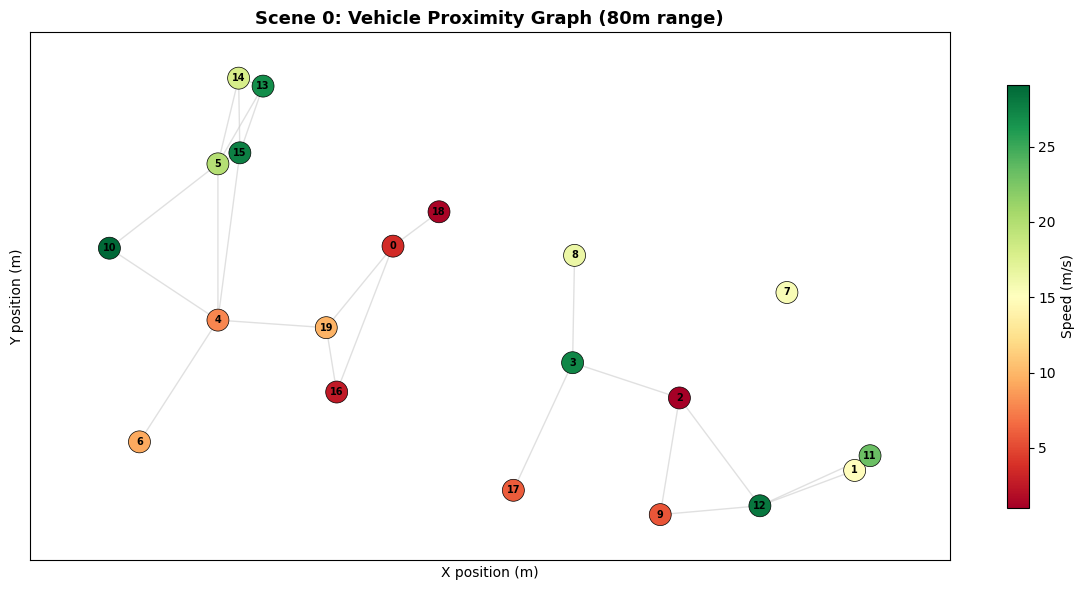

Green = fast vehicles, Red = slow vehicles
Gray lines = edges (vehicles within 80m of each other)


In [ ]:
def visualize_vehicle_graph(graph, features, title='Vehicle Proximity Graph', ax=None):
    """Visualize a vehicle graph with NetworkX."""
    G = nx.Graph()
    n = graph.x.shape[0]

    # Add nodes
    for i in range(n):
        G.add_node(i)

    # Add edges
    edges = graph.edge_index.t().numpy()
    for e in edges:
        if e[0] < e[1]:  # avoid duplicate edges for undirected display
            G.add_edge(e[0], e[1])

    # Node positions from vehicle coordinates
    pos = {i: (features[i, 0], features[i, 1]) for i in range(n)}
    speeds = features[:, 2]

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#cccccc', alpha=0.6, width=1)

    # Draw nodes colored by speed
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=speeds,
                                    cmap='RdYlGn', node_size=250, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='RdYlGn',
                                norm=plt.Normalize(vmin=speeds.min(), vmax=speeds.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Speed (m/s)', shrink=0.8)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('X position (m)')
    ax.set_ylabel('Y position (m)')


# Visualize scene 0
fig, ax = plt.subplots(figsize=(12, 6))
visualize_vehicle_graph(graphs[0], scenes[0], 'Scene 0: Vehicle Proximity Graph (80m range)', ax=ax)
plt.tight_layout()
plt.show()

print('Green = fast vehicles, Red = slow vehicles')
print('Gray lines = edges (vehicles within 80m of each other)')

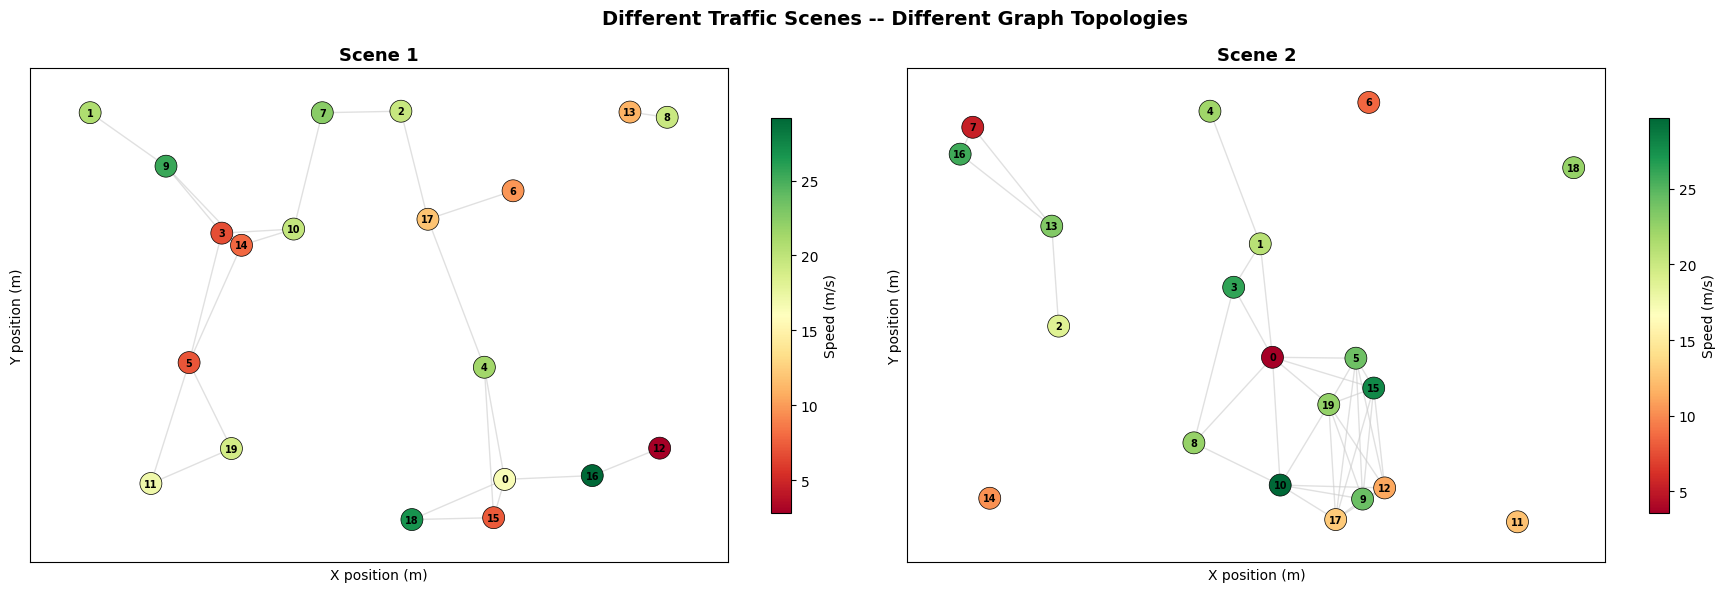

In [ ]:
# Visualize two more scenes for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
visualize_vehicle_graph(graphs[1], scenes[1], 'Scene 1', ax=axes[0])
visualize_vehicle_graph(graphs[2], scenes[2], 'Scene 2', ax=axes[1])
plt.suptitle('Different Traffic Scenes -- Different Graph Topologies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Normalize Features & Split Data

Neural networks work better with normalized inputs. We standardize each feature to zero mean and unit variance.

Split: **70% train, 10% validation, 20% test** (chronological).

In [ ]:
# Flatten all scene features to fit the scaler
all_features = np.concatenate(scenes, axis=0)  # (NUM_SCENES * NUM_VEHICLES, NUM_FEATURES)
all_targets = np.concatenate(targets, axis=0)

feature_scaler = StandardScaler()
feature_scaler.fit(all_features)

target_scaler = StandardScaler()
target_scaler.fit(all_targets.reshape(-1, 1))

# Normalize and rebuild graphs
graphs_normalized = []
for i in range(NUM_SCENES):
    feat_norm = feature_scaler.transform(scenes[i])
    tgt_norm = target_scaler.transform(targets[i].reshape(-1, 1)).flatten()
    g = build_vehicle_graph(scenes[i], tgt_norm)  # edges from original positions
    g.x = torch.tensor(feat_norm, dtype=torch.float32)  # normalized features
    graphs_normalized.append(g)

# Split
n = len(graphs_normalized)
train_end = int(n * 0.7)
val_end = int(n * 0.8)

graphs_train = graphs_normalized[:train_end]
graphs_val = graphs_normalized[train_end:val_end]
graphs_test = graphs_normalized[val_end:]

print(f'Train: {len(graphs_train)}, Val: {len(graphs_val)}, Test: {len(graphs_test)}')

Train: 350, Val: 50, Test: 100


## Step 7: Define the GNN Model

We build a **Graph Convolutional Network (GCN)** where:
- Each vehicle **aggregates sensor data from neighboring vehicles**
- Two GCN layers capture 2-hop neighborhood information
- A linear head predicts the next speed

The model includes a **`predict()`** method for easy inference.

In [ ]:
class VehicleGNN(nn.Module):
    """
    Graph Convolutional Network for vehicle speed prediction.

    Architecture:
        Input (7 sensor features per vehicle)
          -> GCNConv (7 -> 64) + ReLU
          -> GCNConv (64 -> 32) + ReLU
          -> Linear (32 -> 1)  [predict next speed]
    """

    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim // 2)
        self.fc = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x, edge_index):
        # Layer 1: aggregate neighbor sensor data
        x = F.relu(self.conv1(x, edge_index))
        # Layer 2: aggregate 2-hop neighborhood
        x = F.relu(self.conv2(x, edge_index))
        # Output: predict next speed
        return self.fc(x).squeeze(-1)

    def predict(self, graph, device='cpu'):
        """Run inference on a single graph. Returns predicted speeds."""
        self.eval()
        with torch.no_grad():
            x = graph.x.to(device)
            edge_index = graph.edge_index.to(device)
            pred = self.forward(x, edge_index)
        return pred.cpu()


model = VehicleGNN(input_dim=NUM_FEATURES, hidden_dim=64).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

VehicleGNN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 32)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 2,625


## Step 8: Train the Model

We train using:
- **MSE Loss** (Mean Squared Error) for regression
- **Adam optimizer** with adaptive learning rate
- Training over individual graph scenes

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

num_epochs = 50
train_losses = []
val_losses = []

print('Starting training...')
print('-' * 50)

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    epoch_loss = 0
    indices = np.random.permutation(len(graphs_train))

    for i in indices:
        g = graphs_train[i]
        pred = model(g.x.to(device), g.edge_index.to(device))
        loss = criterion(pred, g.y.to(device))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(graphs_train))

    # --- Validation ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for g in graphs_val:
            pred = model(g.x.to(device), g.edge_index.to(device))
            val_loss += criterion(pred, g.y.to(device)).item()

    val_losses.append(val_loss / len(graphs_val))

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Val Loss: {val_losses[-1]:.4f}')

print('-' * 50)
print('Training complete!')

Starting training...
--------------------------------------------------
Epoch [5/50] Train Loss: 0.6267 | Val Loss: 0.6468
Epoch [10/50] Train Loss: 0.6232 | Val Loss: 0.6470
Epoch [15/50] Train Loss: 0.6208 | Val Loss: 0.6486
Epoch [20/50] Train Loss: 0.6183 | Val Loss: 0.6484
Epoch [25/50] Train Loss: 0.6144 | Val Loss: 0.6531
Epoch [30/50] Train Loss: 0.6120 | Val Loss: 0.6484
Epoch [35/50] Train Loss: 0.6082 | Val Loss: 0.6507
Epoch [40/50] Train Loss: 0.6046 | Val Loss: 0.6549
Epoch [45/50] Train Loss: 0.6005 | Val Loss: 0.6553
Epoch [50/50] Train Loss: 0.5973 | Val Loss: 0.6573
--------------------------------------------------
Training complete!


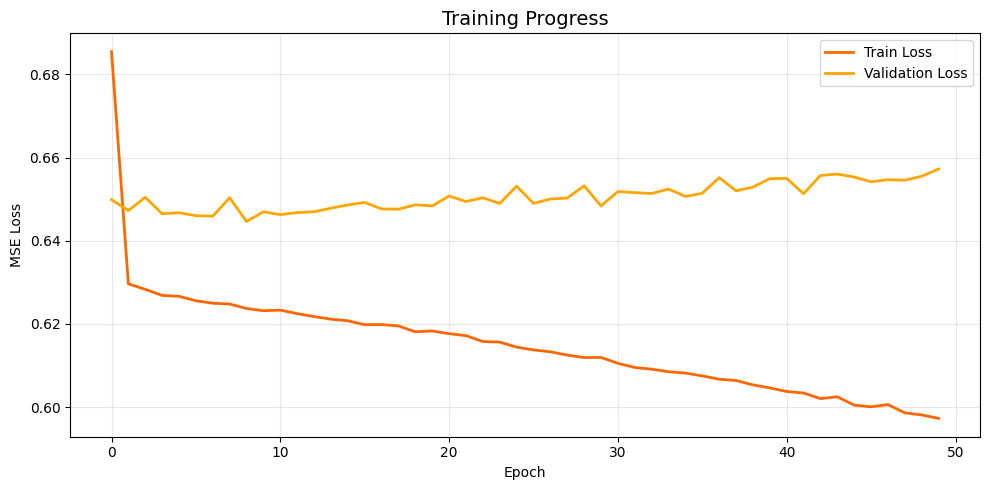

In [ ]:
# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='#FF6600', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='#FFA500', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Progress', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Evaluate with `predict()`

We use the model's **`predict()`** method to run inference on the test set.

In [ ]:
# Evaluate on test set using predict() method
all_preds = []
all_targets = []

for g in graphs_test:
    pred = model.predict(g, device)
    all_preds.append(pred.numpy())
    all_targets.append(g.y.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Metrics on normalized data
mse = np.mean((all_preds - all_targets) ** 2)
mae = np.mean(np.abs(all_preds - all_targets))

# Convert back to original scale (m/s)
preds_original = all_preds * target_scaler.scale_[0] + target_scaler.mean_[0]
targets_original = all_targets * target_scaler.scale_[0] + target_scaler.mean_[0]

mae_ms = np.mean(np.abs(preds_original - targets_original))
rmse_ms = np.sqrt(np.mean((preds_original - targets_original) ** 2))

print(f'Test MSE (normalized): {mse:.4f}')
print(f'Test MAE (normalized): {mae:.4f}')
print(f'\nTest MAE: {mae_ms:.2f} m/s ({mae_ms * 3.6:.2f} km/h)')
print(f'Test RMSE: {rmse_ms:.2f} m/s ({rmse_ms * 3.6:.2f} km/h)')

Test MSE (normalized): 0.6416
Test MAE (normalized): 0.6466

Test MAE: 5.62 m/s (20.24 km/h)
Test RMSE: 6.96 m/s (25.07 km/h)


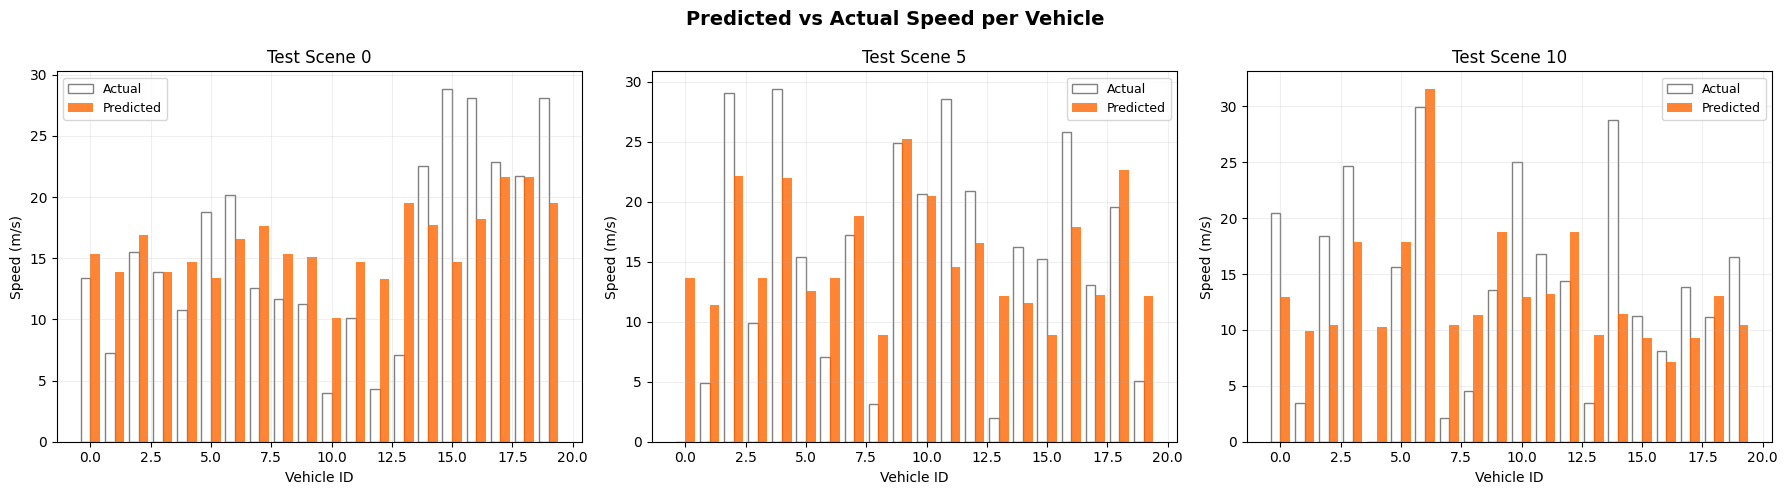

In [ ]:
# Visualize predictions for individual scenes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scene_idx in enumerate([0, 5, 10]):
    g = graphs_test[scene_idx]
    pred = model.predict(g, device).numpy()

    # Convert to original scale
    pred_orig = pred * target_scaler.scale_[0] + target_scaler.mean_[0]
    tgt_orig = g.y.numpy() * target_scaler.scale_[0] + target_scaler.mean_[0]

    vehicle_ids = np.arange(NUM_VEHICLES)
    axes[idx].bar(vehicle_ids - 0.2, tgt_orig, 0.4, label='Actual', color='white', edgecolor='gray')
    axes[idx].bar(vehicle_ids + 0.2, pred_orig, 0.4, label='Predicted', color='#FF6600', alpha=0.8)
    axes[idx].set_xlabel('Vehicle ID')
    axes[idx].set_ylabel('Speed (m/s)')
    axes[idx].set_title(f'Test Scene {scene_idx}', fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.2)

plt.suptitle('Predicted vs Actual Speed per Vehicle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

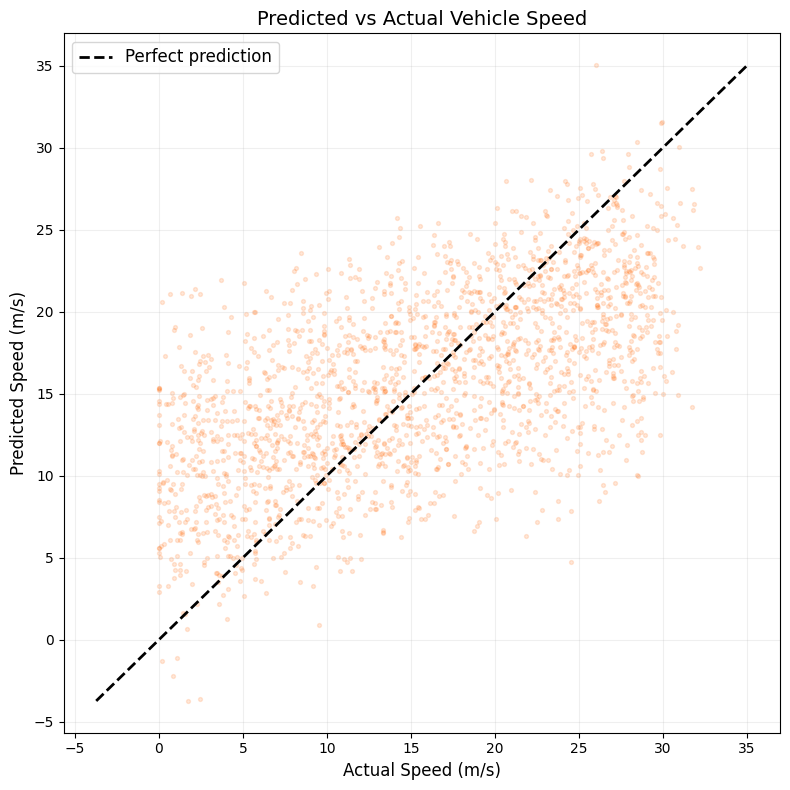

Points close to the diagonal = good predictions!


In [ ]:
# Scatter plot: predicted vs actual
plt.figure(figsize=(8, 8))
plt.scatter(targets_original, preds_original, alpha=0.15, s=8, color='#FF6600')
lims = [min(targets_original.min(), preds_original.min()),
        max(targets_original.max(), preds_original.max())]
plt.plot(lims, lims, 'k--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Speed (m/s)', fontsize=12)
plt.ylabel('Predicted Speed (m/s)', fontsize=12)
plt.title('Predicted vs Actual Vehicle Speed', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print('Points close to the diagonal = good predictions!')

## Summary

**What we built:**
- A **Graph Convolutional Network** for vehicle speed prediction
- Each **node = a vehicle** with a sensor feature vector `[x, y, speed, heading, accel, lidar, camera]`
- Edges connect vehicles within **80m proximity**
- The GCN learns spatial patterns: how neighboring vehicles influence each other

**Key takeaway:**
> By modeling vehicles as a graph, our GNN understands that a vehicle's future speed depends on **nearby vehicles' sensor data** -- not just its own sensors.

**Next: Demo 2** -- We'll enhance this model by adding **V2X communication edges** and compare the improvement!